# XBTorch::Example 01:Device Models & Conductance Sweeping  

## Introduction

In this example, we will investigate conductance trajectories using different device models from XBTorch.

XBTorch supports two kinds of device models. Within each type, it further provides several presets. One can either use these presets directly, or utilize the base device model class with custom parameters.

1) **Analytical**
    1) AnalyticalIdeal
    2) AnalyticalReal
2) **Tabular**
    1) TabularAnalyticalReal

The primary difference between the two models is how the conductance update is simulated. The analytical models rely directly on the mathematical formulation from the NeuroSim-herd of device models and its derivatives [1], whereas tabular models rely on the data-driven jump table modeling methodology from our previous work [2].

## Getting Started

Let's import necessary dependencies and write a helper function to assist in visualization.

In [1]:
# General Imports
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# XBTorch imports
from xbtorch.devices.presets import AnalyticalIdeal, AnalyticalReal, TabularAnalyticalReal # analytical models
from xbtorch.devices.base import AnalyticalDevice
from xbtorch.devices.utils import sweep_conductance_full

W0930 13:21:04.793000 1605594 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0930 13:21:04.793000 1605594 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.


In [3]:
# Let's write a simple plotting function
def plot_G_vs_pulse(device, cycles=1, title=''):
    """
        Plot conductance (G) trajectories.
        A conductance trajectory is obtained by applying sequential voltage pulses to a device.

        Inputs 
            device: the XBTorch device model object.
            cycle: total number of cycles to repeat the sweeping process.
    """

    set_Gs, reset_Gs = np.zeros((cycles, device.max_level+1)), np.zeros((cycles, device.max_level+1))

    for cycle in range(cycles): set_Gs[cycle], reset_Gs[cycle] = sweep_conductance_full(device)

    plt.figure()
    plt.plot(range(0, device.max_level+1), np.average(set_Gs, axis=0), label='SET')
    plt.fill_between(range(0, device.max_level+1), np.average(set_Gs, axis=0) - np.std(set_Gs, axis=0), np.average(set_Gs, axis=0) + np.std(set_Gs, axis=0), alpha=0.2)

    plt.plot(range(device.max_level, device.max_level*2+1), np.average(reset_Gs, axis=0), label='RESET')
    plt.fill_between(range(device.max_level, device.max_level*2+1), np.average(reset_Gs, axis=0) - np.std(reset_Gs, axis=0), np.average(reset_Gs, axis=0) + np.std(reset_Gs, axis=0), alpha=0.2)

    plt.legend()
    plt.xlabel('Pulse (#)')
    plt.ylabel('Conductance (S)')

    plt.title(title)

    return set_Gs, reset_Gs

## Simulating Devices

We can now instantiate different device models from XBTorch and observe how conductance trajectories differ from one model to another. Let's see this in action using different device models and presets!

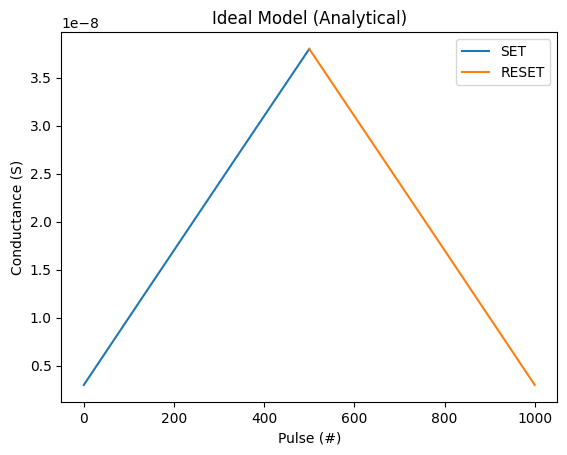

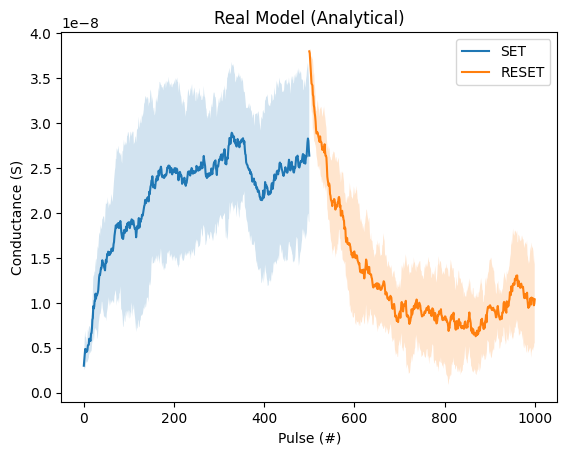

In [4]:
# Analytical Device Model Presets - AnalyticalIdeal and AnalyticalReal
deviceIdeal = AnalyticalIdeal()
deviceReal =  AnalyticalReal()

p1 = plot_G_vs_pulse(deviceIdeal, cycles=10, title='Ideal Model (Analytical)')
p2 = plot_G_vs_pulse(deviceReal, cycles=10, title='Real Model (Analytical)')

We can customize the presets as well. Here's an example of a device with non-linearity but no cycle-to-cycle variability.

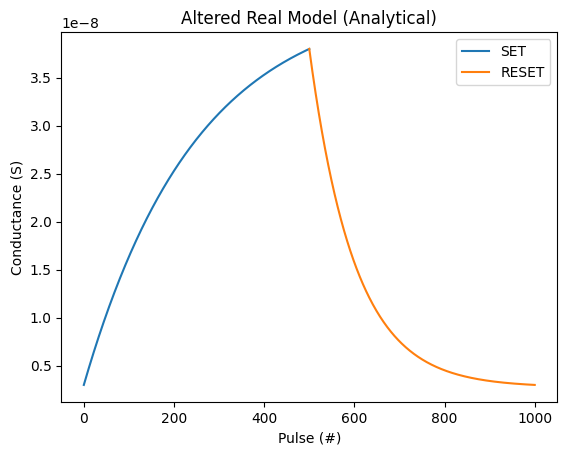

In [5]:
deviceRealAltered =  AnalyticalReal()
deviceRealAltered.c2c_var = 0.0

p3 = plot_G_vs_pulse(deviceRealAltered, cycles=10, title='Altered Real Model (Analytical)')

As mentioned above, we can also utilize the base class and instantiate a custom model instead of relying on the provided preset completely. Here's an example of a using custom parameters with the base analytical model class. This gives us direct control over device-level non-idealities.

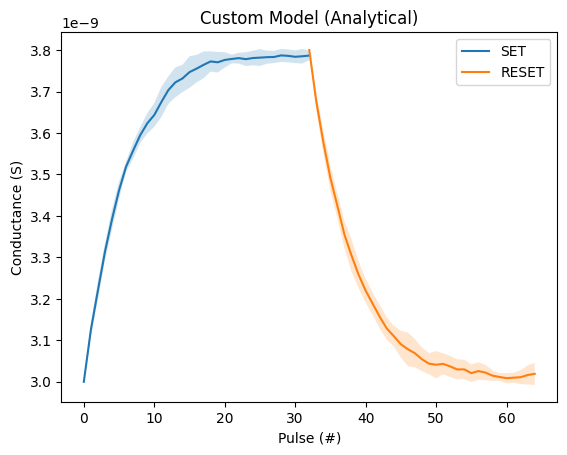

In [6]:
# Alternately, fitted parameters can be directly utilized as well
deviceCustom = AnalyticalDevice(min_conductance=3e-9, max_conductance=3.8e-9, d2d_var=0.05, c2c_var=0.02, nonlinearity_set=5, nonlinearity_reset=-5, max_level=32)
p4 = plot_G_vs_pulse(deviceCustom, cycles=10, title='Custom Model (Analytical)')

Finally, we can also utilize tabular device models and tabular device model presets. Here's an example of a tabular model that matches the analytical real model in terms of its conductance trajectories. If sources of randomness were fixed, then trajectories produced by this model would perfectly align with those produced by the `AnalyticalReal` preset.

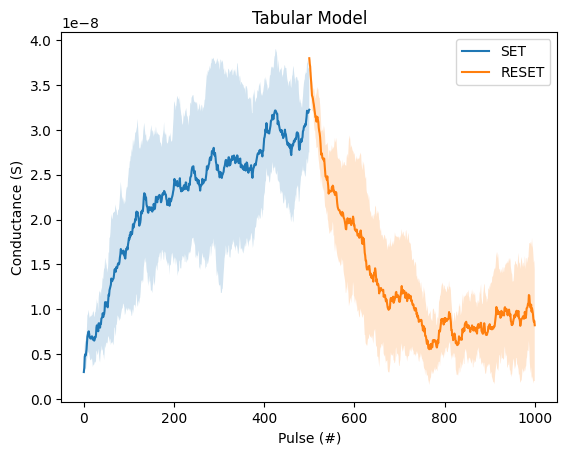

In [7]:
# Tabular Device Models
tabularDev = TabularAnalyticalReal()
p5 = plot_G_vs_pulse(tabularDev, cycles=10, title='Tabular Model')

## Conclusion
We now know how to extract conductance trajectories for building device models. When building custom models, this should be one of the first sanity checks to ensure correctness. If you want to dive deeper into how the simulated devices are getting pulsed, looking into `sweep_conductance_full()` from `xbtorch.devices.utils` would be the recommended place to start!

## References
1. Peng, X., Huang, S., Jiang, H., Lu, A., & Yu, S. (2020). DNN+NeuroSim V2.0: An end-to-end benchmarking framework for compute-in-memory accelerators for on-chip training. IEEE Transactions on Computer-Aided Design of Integrated Circuits and Systems, 40(11), 2306-2319.
2. Yousuf, O., Hossen, I., Daniels, M. W., Lueker-Boden, M., Dienstfrey, A., & Adam, G. C. (2023). Device Modeling Bias in ReRAM-based Neural Network Simulations. IEEE Journal on Emerging and Selected Topics in Circuits and Systems, 13(1), 382-394.